<a href="https://colab.research.google.com/github/CodeKoala995/northstar-analytics/blob/main/sql_r_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
base_url <- "https://raw.githubusercontent.com/CodeKoala995/northstar-analytics/main/"
customers <- read.csv(paste0(base_url, "customers.csv"))
orders <- read.csv(paste0(base_url, "orders.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
complaints <- read.csv(paste0(base_url, "complaints.csv"))
drivers <- read.csv(paste0(base_url, "drivers.csv"))
vehicles <- read.csv(paste0(base_url, "vehicles.csv"))
hubs <- read.csv(paste0(base_url, "hubs.csv"))
incidents <- read.csv(paste0(base_url, "incidents.csv"))
app_events <- read.csv(paste0(base_url, "app_events.csv"))
cat("All files loaded!\n")

All files loaded!


In [3]:
cat("ORDERS:\n")
print(names(orders))

cat("\nDELIVERIES:\n")
print(names(deliveries))

cat("\nCOMPLAINTS:\n")
print(names(complaints))

cat("\nCUSTOMERS:\n")
print(names(customers))

cat("\nDRIVERS:\n")
print(names(drivers))

cat("\nHUBS:\n")
print(names(hubs))

cat("\nINCIDENTS:\n")
print(names(incidents))

ORDERS:
 [1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

DELIVERIES:
 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"          

COMPLAINTS:
 [1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation

In [ ]:
install.packages("sqldf")
install.packages("ggplot2")
library(sqldf)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [ ]:
# SECTION 1: DATA EXPLORATION

# Check dimensions of each table
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")
cat("Customers:", nrow(customers), "rows\n")
cat("Drivers:", nrow(drivers), "rows\n")
cat("Hubs:", nrow(hubs), "rows\n")
cat("Incidents:", nrow(incidents), "rows\n")

Orders: 1250 rows
Deliveries: 950 rows
Complaints: 320 rows
Customers: 650 rows
Drivers: 170 rows
Hubs: 8 rows
Incidents: 280 rows


In [ ]:
# SECTION 2: DATA QUALITY CHECK

cat("Missing values in Orders:\n")
print(colSums(is.na(orders)))

cat("\nMissing values in Deliveries:\n")
print(colSums(is.na(deliveries)))

cat("\nMissing values in Complaints:\n")
print(colSums(is.na(complaints)))

Missing values in Orders:
             order_id           customer_id          service_type 
                    0                     0                     0 
     order_created_at promised_window_hours           pickup_zone 
                    0                     0                     0 
         dropoff_zone        priority_level           order_value 
                    0                     0                     0 
      booking_channel special_handling_flag 
                    0                     0 

Missing values in Deliveries:
                  delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                        

In [4]:
# FIX 1: Standardise zone names

orders$pickup_zone <- toupper(trimws(orders$pickup_zone))
orders$dropoff_zone <- toupper(trimws(orders$dropoff_zone))
customers$home_zone <- toupper(trimws(customers$home_zone))
drivers$base_zone <- toupper(trimws(drivers$base_zone))
hubs$zone <- toupper(trimws(hubs$zone))

cat("Zone names standardised!\n")
print(table(orders$pickup_zone))

Zone names standardised!

  AIRPORT   CENTRAL       CTR      EAST     NORTH RIVERSIDE     SOUTH      WEST 
      144       158        80       207       174       151       181       155 


In [ ]:
# SQL QUERY 1 FIXED: Delivery failure rate by zone
# Business question: Which zones have the most failed deliveries?

failure_by_zone <- sqldf("
  SELECT
    o.pickup_zone AS zone,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

print(failure_by_zone)

       zone total_deliveries failed_deliveries failure_rate_pct
1   CENTRAL              110                22            20.00
2       CTR               64                11            17.19
3     NORTH              135                22            16.30
4 RIVERSIDE              119                18            15.13
5      WEST              114                14            12.28
6      EAST              156                19            12.18
7   AIRPORT              113                12            10.62
8     SOUTH              139                14            10.07
  avg_customer_rating
1                3.62
2                3.43
3                3.90
4                3.86
5                3.90
6                3.91
7                3.98
8                4.05


In [ ]:
cat("Delivery status values:\n")
print(table(deliveries$delivery_status))

cat("\nPickup zone values:\n")
print(table(orders$pickup_zone))

Delivery status values:

Delayed  Failed  OnTime 
    202     132     616 

Pickup zone values:

  Airport   AIRPORT   Central   CENTRAL       Ctr      East      EAST     north 
       85        59        79        79        80       104       103        64 
    North     NORTH Riverside RiverSide     South     SOUTH      West      WEST 
       50        60        65        86       103        78        71        84 


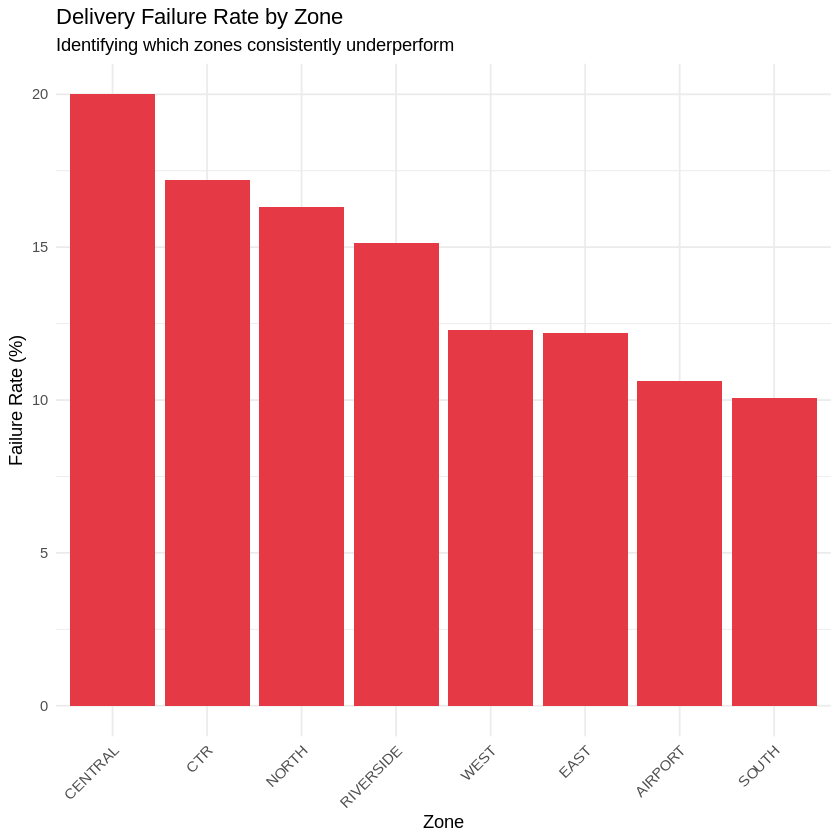

In [ ]:
# Visualise failure rate by zone
ggplot(failure_by_zone, aes(x = reorder(zone, -failure_rate_pct), y = failure_rate_pct)) +
  geom_bar(stat = "identity", fill = "#E63946") +
  labs(
    title = "Delivery Failure Rate by Zone",
    subtitle = "Identifying which zones consistently underperform",
    x = "Zone",
    y = "Failure Rate (%)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
# SQL QUERY 2: Complaints linked to failed deliveries
# Business question: Are complaints concentrated around failed deliveries?

complaints_vs_failures <- sqldf("
  SELECT
    d.delivery_status,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY d.delivery_status
  ORDER BY total_complaints DESC
")

print(complaints_vs_failures)

  delivery_status total_complaints avg_resolution_days avg_compensation
1          OnTime              149                7.60            19.18
2         Delayed               48                7.63            18.36
3          Failed               35                9.66            25.47


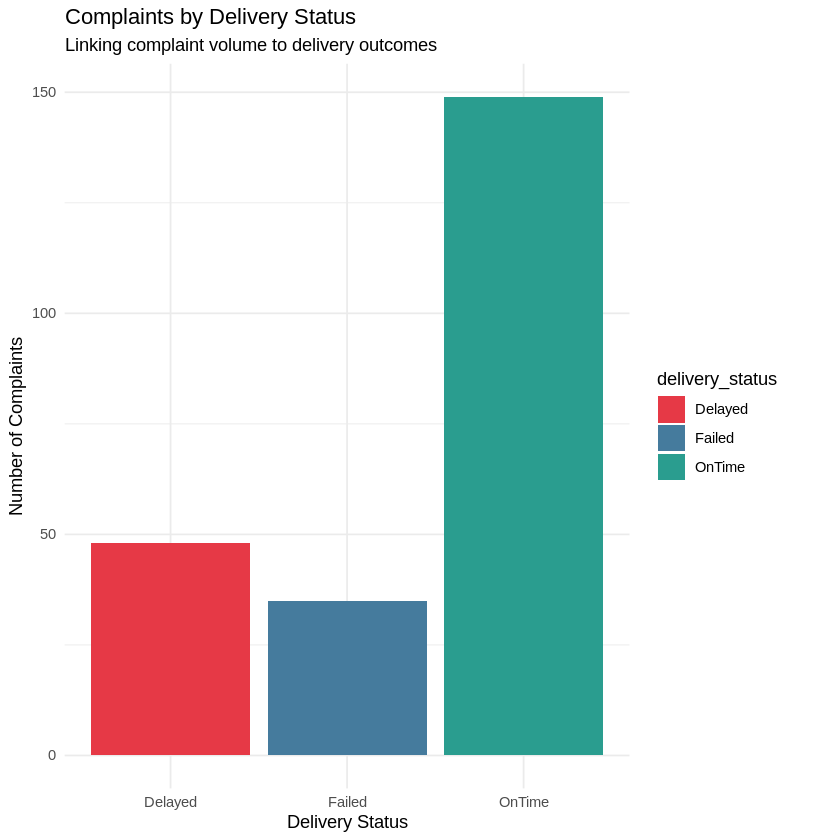

In [ ]:
ggplot(complaints_vs_failures, aes(x = delivery_status, y = total_complaints, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaints by Delivery Status",
    subtitle = "Linking complaint volume to delivery outcomes",
    x = "Delivery Status",
    y = "Number of Complaints"
  ) +
  theme_minimal() +
  scale_fill_manual(values = c("#E63946", "#457B9D", "#2A9D8F", "#F4A261"))

In [ ]:
# SQL QUERY 3: Driver performance vs incidents
# Business question: Do lower rated drivers have more incidents?

driver_performance <- sqldf("
  SELECT
    dr.driver_id,
    dr.driver_rating,
    dr.training_score,
    dr.base_zone,
    COUNT(i.incident_id) AS total_incidents,
    ROUND(AVG(i.resolved_hours), 2) AS avg_resolution_hours
  FROM drivers dr
  LEFT JOIN deliveries d ON dr.driver_id = d.driver_id
  LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY dr.driver_id
  ORDER BY total_incidents DESC
  LIMIT 20
")

print(driver_performance)

   driver_id driver_rating training_score base_zone total_incidents
1       D039          4.06           86.1   AIRPORT               7
2       D087          4.43           73.3     NORTH               6
3       D146          4.36             NA   AIRPORT               5
4       D132          4.20           77.6     SOUTH               5
5       D026          3.15           84.9     NORTH               5
6       D004          4.75           88.9   AIRPORT               5
7       D154          4.35           67.0   AIRPORT               4
8       D140          3.92           80.1     NORTH               4
9       D119          3.55           56.0     SOUTH               4
10      D108          4.33           70.6     SOUTH               4
11      D094          4.48           60.8       CTR               4
12      D088          4.17           84.3 RIVERSIDE               4
13      D084          3.99           47.2   CENTRAL               4
14      D069          5.00           61.5     NO

`geom_smooth()` using formula = 'y ~ x'


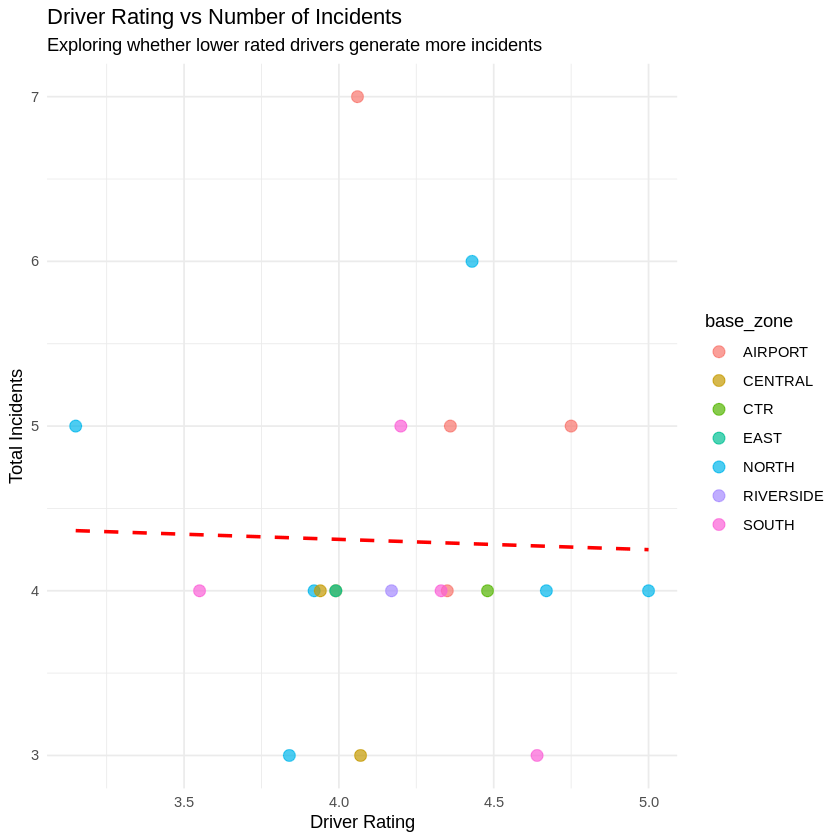

In [ ]:
ggplot(driver_performance, aes(x = driver_rating, y = total_incidents)) +
  geom_point(aes(color = base_zone), size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") +
  labs(
    title = "Driver Rating vs Number of Incidents",
    subtitle = "Exploring whether lower rated drivers generate more incidents",
    x = "Driver Rating",
    y = "Total Incidents"
  ) +
  theme_minimal()

In [ ]:
# SQL QUERY 4: Hub utilisation vs delivery cost
# Business question: Are high cost deliveries concentrated at certain hubs?

hub_costs <- sqldf("
  SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    ROUND(AVG(d.route_distance_km), 2) AS avg_distance_km,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM hubs h
  JOIN deliveries d ON h.hub_id = d.hub_id
  GROUP BY h.hub_id
  ORDER BY avg_cost DESC
")

print(hub_costs)

        hub_name      zone  hub_type total_deliveries avg_cost avg_distance_km
1   Central Core   CENTRAL   Control              115    13.69           14.32
2    Airport Hub   AIRPORT  Dispatch              104    13.32           14.41
3      West Gate      WEST  Dispatch              127    13.17           13.38
4  Riverside Hub RIVERSIDE Warehouse              115    12.92           14.29
5 North Exchange     NORTH  Dispatch              136    12.76           13.64
6      East Dock      EAST Warehouse              119    12.74           14.52
7     South Link     SOUTH  Dispatch              106    12.57           14.17
8  Midtown Relay   CENTRAL  Charging              128    11.71           12.82
  failed_count avg_rating
1           23       3.67
2           15       3.88
3           16       3.92
4           14       3.88
5           17       3.84
6           11       3.90
7           10       3.95
8           26       3.88


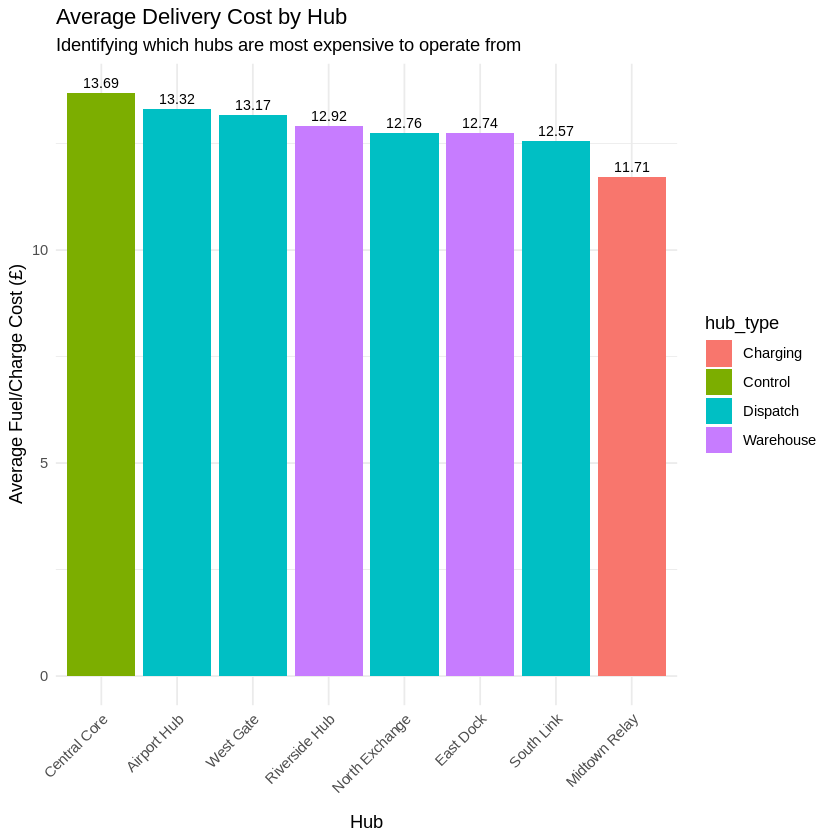

In [ ]:
ggplot(hub_costs, aes(x = reorder(hub_name, -avg_cost), y = avg_cost, fill = hub_type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = avg_cost), vjust = -0.5, size = 3) +
  labs(
    title = "Average Delivery Cost by Hub",
    subtitle = "Identifying which hubs are most expensive to operate from",
    x = "Hub",
    y = "Average Fuel/Charge Cost (£)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
# SQL QUERY 5: Identifying relational database limitations
# Business question: How many orders have multiple complaints?

multi_complaint_orders <- sqldf("
  SELECT
    o.order_id,
    o.service_type,
    o.pickup_zone,
    o.order_value,
    COUNT(c.complaint_id) AS complaint_count,
    GROUP_CONCAT(c.complaint_type, ' | ') AS complaint_types,
    GROUP_CONCAT(c.channel, ' | ') AS channels_used
  FROM orders o
  JOIN complaints c ON o.order_id = c.order_id
  GROUP BY o.order_id
  HAVING COUNT(c.complaint_id) > 1
  ORDER BY complaint_count DESC
  LIMIT 20
")

print(multi_complaint_orders)
cat("\nTotal orders with multiple complaints:", nrow(multi_complaint_orders), "\n")

   order_id service_type pickup_zone order_value complaint_count
1    O00795       Retail   RIVERSIDE       42.52               3
2    O00125       Retail        WEST       70.05               3
3    O01157       Parcel   RIVERSIDE      123.37               2
4    O01151       Retail       SOUTH       94.09               2
5    O01131      Medical     AIRPORT      150.77               2
6    O01125       Parcel        WEST       47.38               2
7    O01104       Parcel        EAST       55.13               2
8    O00980       Parcel        WEST      510.06               2
9    O00950    Passenger       SOUTH       82.99               2
10   O00948     Business       NORTH       60.77               2
11   O00920    Passenger   RIVERSIDE       74.71               2
12   O00838    Passenger         CTR       48.73               2
13   O00801       Retail       SOUTH      111.28               2
14   O00751     Business       NORTH      152.61               2
15   O00737       Retail 

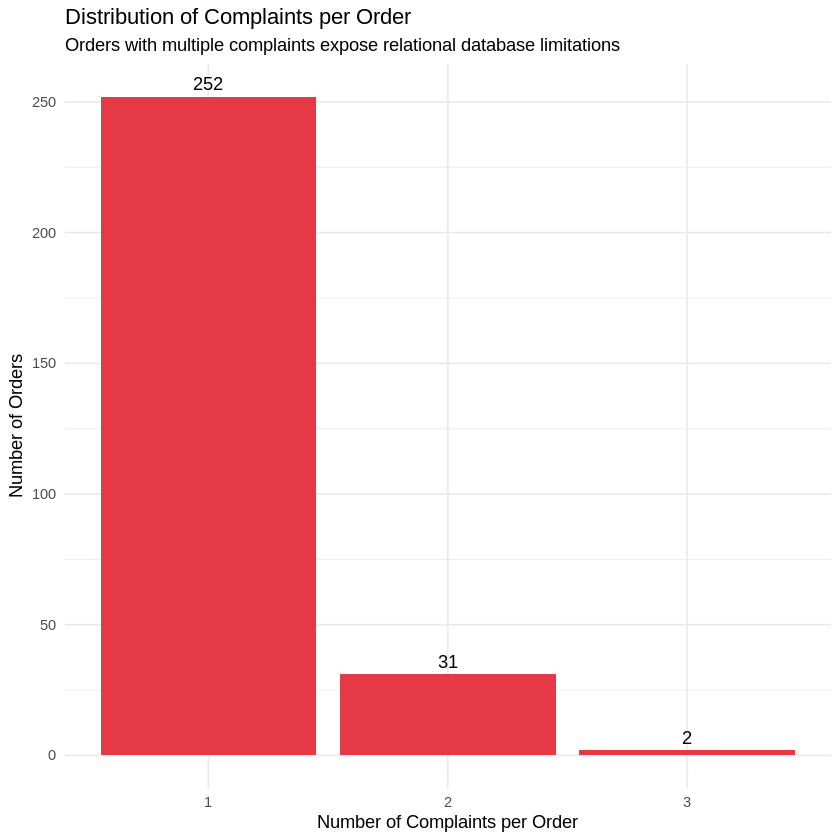

In [ ]:
# Count complaints per order for distribution chart
complaint_distribution <- sqldf("
  SELECT
    COUNT(c.complaint_id) AS complaint_count,
    COUNT(o.order_id) AS number_of_orders
  FROM orders o
  JOIN complaints c ON o.order_id = c.order_id
  GROUP BY o.order_id
")

ggplot(complaint_distribution, aes(x = factor(complaint_count))) +
  geom_bar(fill = "#E63946") +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
  labs(
    title = "Distribution of Complaints per Order",
    subtitle = "Orders with multiple complaints expose relational database limitations",
    x = "Number of Complaints per Order",
    y = "Number of Orders"
  ) +
  theme_minimal()

In [ ]:
# SQL QUERY 6: Manual route overrides by zone
# Business question: Which zones have drivers overriding routes most?

route_overrides <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(d.manual_route_override_count) AS total_overrides,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides_per_delivery,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY avg_overrides_per_delivery DESC
")

print(route_overrides)

  pickup_zone total_deliveries total_overrides avg_overrides_per_delivery
1     AIRPORT              113             204                       1.81
2     CENTRAL              110             178                       1.62
3        WEST              114              92                       0.81
4        EAST              156             123                       0.79
5   RIVERSIDE              119              87                       0.73
6         CTR               64              47                       0.73
7       NORTH              135              94                       0.70
8       SOUTH              139              96                       0.69
  avg_cost failed_deliveries
1    17.08                12
2    12.15                22
3    11.94                14
4    12.57                19
5    12.39                18
6    12.07                11
7    12.07                22
8    12.48                14


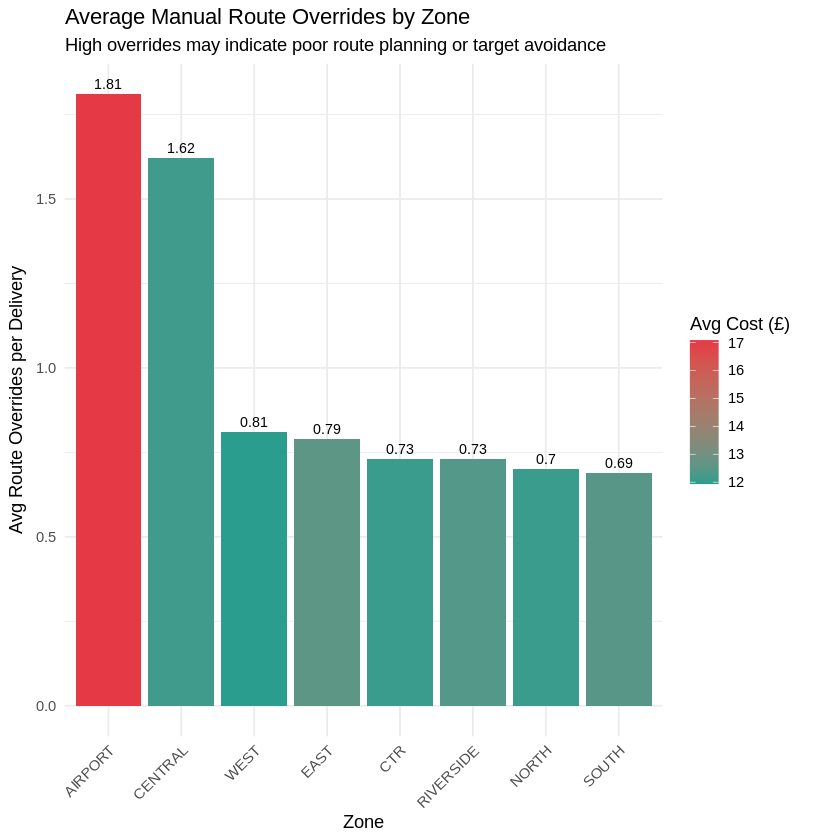

In [ ]:
ggplot(route_overrides, aes(x = reorder(pickup_zone, -avg_overrides_per_delivery),
                             y = avg_overrides_per_delivery, fill = avg_cost)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = avg_overrides_per_delivery), vjust = -0.5, size = 3) +
  scale_fill_gradient(low = "#2A9D8F", high = "#E63946") +
  labs(
    title = "Average Manual Route Overrides by Zone",
    subtitle = "High overrides may indicate poor route planning or target avoidance",
    x = "Zone",
    y = "Avg Route Overrides per Delivery",
    fill = "Avg Cost (£)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
# SQL QUERY 7: Performance by service type
# Business question: Which service type performs worst?

service_performance <- sqldf("
  SELECT
    o.service_type,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    SUM(CASE WHEN d.proof_of_completion_missing = 1 THEN 1 ELSE 0 END) AS missing_proof_count
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY avg_customer_rating ASC
")

print(service_performance)

  service_type total_deliveries avg_customer_rating failed_deliveries
1      Medical              108                3.84                16
2     Business              126                3.85                25
3    Passenger              262                3.85                38
4       Retail              224                3.87                28
5       Parcel              230                3.90                25
  delayed_deliveries avg_cost missing_proof_count
1                 22    12.77                   7
2                 28    13.14                   7
3                 53    12.40                  18
4                 50    12.97                  18
5                 49    13.08                  19


In [ ]:
install.packages("tidyr")
library(tidyr)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




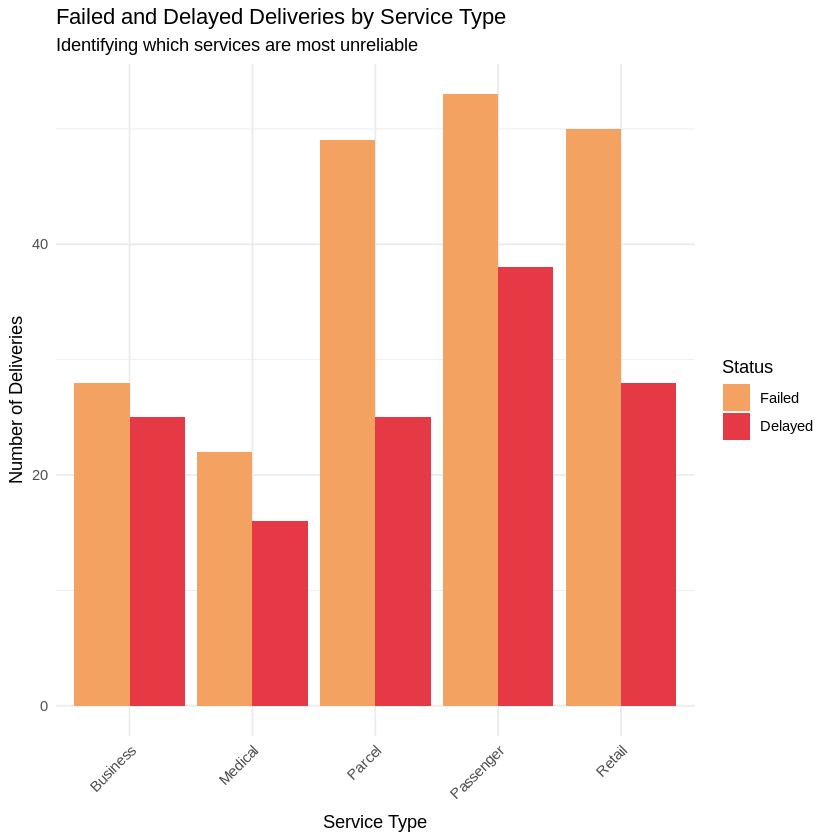

In [ ]:
library(tidyr)

# Reshape for grouped bar chart
service_long <- service_performance %>%
  select(service_type, failed_deliveries, delayed_deliveries) %>%
  pivot_longer(cols = c(failed_deliveries, delayed_deliveries),
               names_to = "status",
               values_to = "count")

ggplot(service_long, aes(x = service_type, y = count, fill = status)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("failed_deliveries" = "#E63946",
                                "delayed_deliveries" = "#F4A261"),
                    labels = c("Failed", "Delayed")) +
  labs(
    title = "Failed and Delayed Deliveries by Service Type",
    subtitle = "Identifying which services are most unreliable",
    x = "Service Type",
    y = "Number of Deliveries",
    fill = "Status"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
# SQL QUERY 8: High value orders vs delivery success
# Business question: Are high value orders being protected?

value_vs_success <- sqldf("
  SELECT
    CASE
      WHEN o.order_value < 50 THEN 'Low (under 50)'
      WHEN o.order_value BETWEEN 50 AND 150 THEN 'Medium (50-150)'
      ELSE 'High (over 150)'
    END AS order_value_band,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  LEFT JOIN complaints c ON o.order_id = c.order_id
  GROUP BY order_value_band
  ORDER BY total_orders DESC
")

print(value_vs_success)

  order_value_band total_orders failed delayed avg_rating avg_compensation
1  Medium (50-150)          566     84     113       3.87            19.85
2   Low (under 50)          251     30      61       3.89            21.91
3  High (over 150)          156     20      31       3.84            17.63


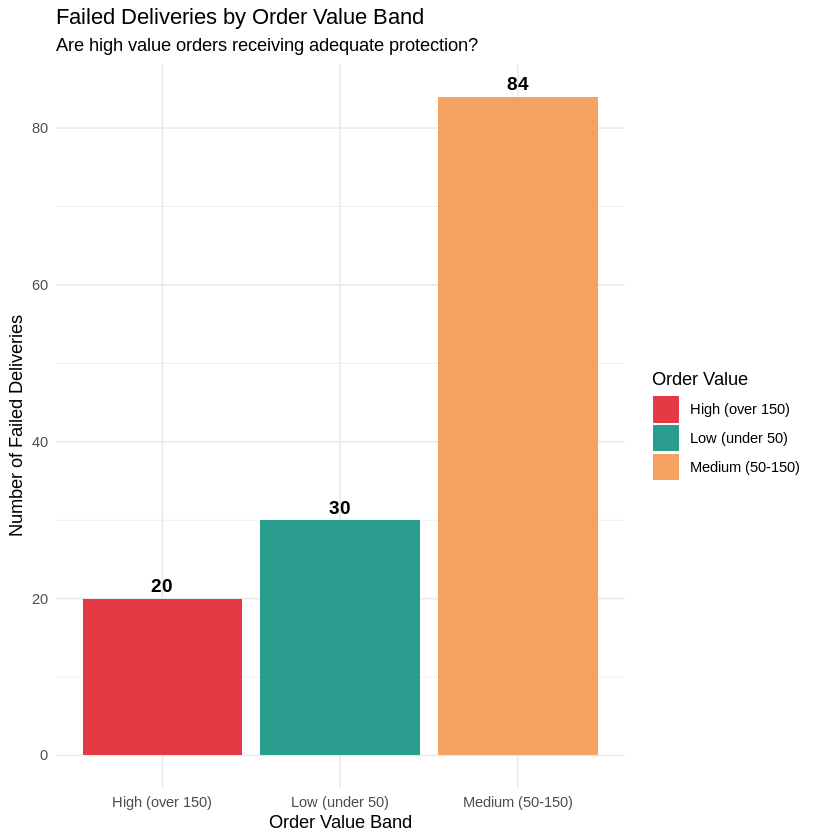

In [ ]:
ggplot(value_vs_success, aes(x = order_value_band, y = failed, fill = order_value_band)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = failed), vjust = -0.5, size = 4, fontface = "bold") +
  scale_fill_manual(values = c(
    "Low (under 50)" = "#2A9D8F",
    "Medium (50-150)" = "#F4A261",
    "High (over 150)" = "#E63946"
  )) +
  labs(
    title = "Failed Deliveries by Order Value Band",
    subtitle = "Are high value orders receiving adequate protection?",
    x = "Order Value Band",
    y = "Number of Failed Deliveries",
    fill = "Order Value"
  ) +
  theme_minimal()

In [ ]:
# SQL QUERY 9: Complaint resolution time by zone and severity
# Business question: Are complaints resolved fairly across zones?

resolution_by_zone <- sqldf("
  SELECT
    o.pickup_zone,
    c.severity,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,
    SUM(CASE WHEN c.status = 'Open' THEN 1 ELSE 0 END) AS still_open
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.pickup_zone, c.severity
  ORDER BY avg_resolution_days DESC
")

print(resolution_by_zone)

   pickup_zone severity total_complaints avg_resolution_days avg_compensation
1        SOUTH     High                6               14.67            39.75
2         WEST     High               10               14.20            42.75
3        NORTH     High               18               14.06            37.28
4          CTR     High                5               12.80            29.60
5      CENTRAL     High               14               12.50            42.12
6         EAST     High               12               12.17            41.65
7    RIVERSIDE     High                9               12.00            34.09
8      AIRPORT     High                3               11.33            42.32
9        SOUTH      Low               15                8.00             8.12
10   RIVERSIDE      Low                8                7.88            11.55
11     AIRPORT   Medium               23                7.17            14.06
12       NORTH   Medium               21                6.67    

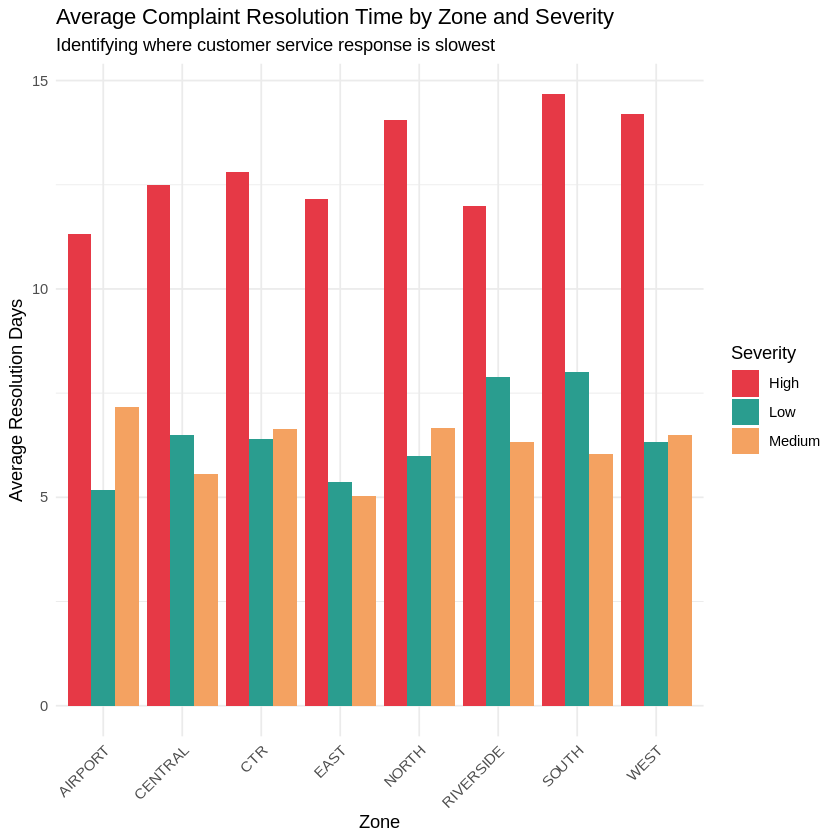

In [ ]:
ggplot(resolution_by_zone, aes(x = pickup_zone, y = avg_resolution_days, fill = severity)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Average Complaint Resolution Time by Zone and Severity",
    subtitle = "Identifying where customer service response is slowest",
    x = "Zone",
    y = "Average Resolution Days",
    fill = "Severity"
  ) +
  scale_fill_manual(values = c(
    "Low" = "#2A9D8F",
    "Medium" = "#F4A261",
    "High" = "#E63946"
  )) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))